## What Are Regression Metrics?

Regression metrics are numerical measures used to evaluate how well a regression model predicts **continuous target values**. Unlike classification tasks (which predict discrete labels like "spam / not spam"), regression tasks predict quantities — such as house prices, student salaries, temperatures, or delivery times — and regression metrics tell us **how far off the predictions are from the true values**.

---

### Why Regression Metrics Matter

When building a model, we need an objective way to answer:

- **Is the model accurate?** — How large are the errors on average?
- **Is it improving?** — Are errors getting smaller as we tune features or hyperparameters?
- **Which model is better?** — When comparing two models, which one generalizes to unseen data?
- **Does the model explain the data?** — What fraction of the target's variation is the model capturing?

A single metric rarely tells the whole story. Using multiple metrics together gives a **complete picture of model performance**.

---

### Where Regression Metrics Are Used

Regression metrics are applied anywhere a model predicts a **numerical output**:

| Domain | Example Target | Common Metrics Used |
|:---|:---|:---|
| **Recruitment / HR** | Salary / package prediction | MAE, Adjusted R² |
| **Real Estate** | House price prediction | MAE, RMSE |
| **Finance** | Stock price forecasting | RMSE, R² |
| **Healthcare** | Patient recovery time, drug dosage | MAE, RMSE |
| **E-Commerce** | Demand forecasting, delivery time | MAE, RMSLE |
| **Energy** | Power consumption forecasting | RMSE, MAPE |
| **Climate Science** | Temperature, rainfall forecasting | RMSE, R² |

---

### The Core Concept: Residuals

For every prediction $\hat{y}_i$ against the true value $y_i$, the **error (residual)** is:

$$e_i = y_i - \hat{y}_i$$

Positive residual → model **under-predicted** | Negative residual → model **over-predicted**

Regression metrics aggregate these residuals in different ways:
- **Error-based metrics** (MAE, MSE, RMSE) → report the *size* of errors
- **Goodness-of-fit metrics** (R², Adjusted R²) → report *how much variation* the model explains

---

### Metrics Covered in This Notebook

This notebook evaluates a Linear Regression model (CGPA → Placement Package) using **5 key regression metrics**:

| # | Metric | What It Measures | Better When |
|:---:|:---|:---|:---:|
| 1 | **MAE** | Average absolute error (same units as target) | Lower ↓ |
| 2 | **MSE** | Average squared error (penalizes large errors) | Lower ↓ |
| 3 | **RMSE** | Square root of MSE (back to original units) | Lower ↓ |
| 4 | **R²** | Proportion of target variance explained by model | Higher ↑ (max = 1) |
| 5 | **Adjusted R²** | R² penalized for adding irrelevant features | Higher ↑ (max = 1) |

# Regression Metrics - A Comprehensive Guide

This notebook demonstrates different regression evaluation metrics used to assess the performance of linear regression models.

## Topics Covered:
1. **Mean Absolute Error (MAE)** - Average absolute difference between predicted and actual values
2. **Mean Squared Error (MSE)** - Average squared difference between predicted and actual values
3. **Root Mean Squared Error (RMSE)** - Square root of MSE
4. **R² Score** - Coefficient of determination
5. **Adjusted R² Score** - R² adjusted for number of features

---

## 1. Import Libraries

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## 2. Load and Explore Data

We'll use a placement dataset that contains CGPA and package information of students.

In [2]:
df = pd.read_csv('placement.csv')

In [3]:
df.head()
df.shape

(200, 2)

Text(0, 0.5, 'Package(in lpa)')

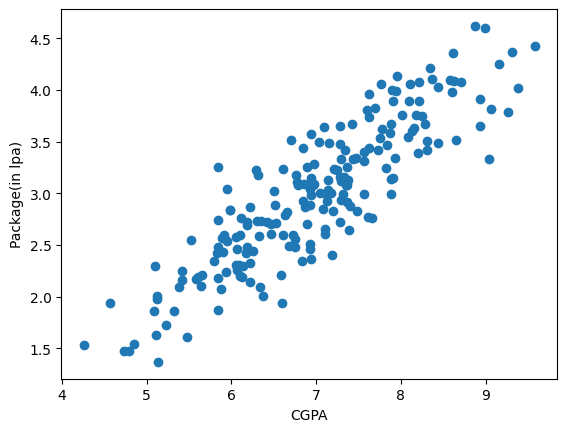

In [4]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

## 3. Prepare Data for Training

Split the data into features (X) and target variable (y), then create train-test splits.

In [4]:
X = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [6]:
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

## 4. Build Linear Regression Model

Create and train a simple linear regression model using scikit-learn.

In [6]:
from sklearn.linear_model import LinearRegression

In [7]:
lr = LinearRegression()

In [8]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Text(0, 0.5, 'Package(in lpa)')

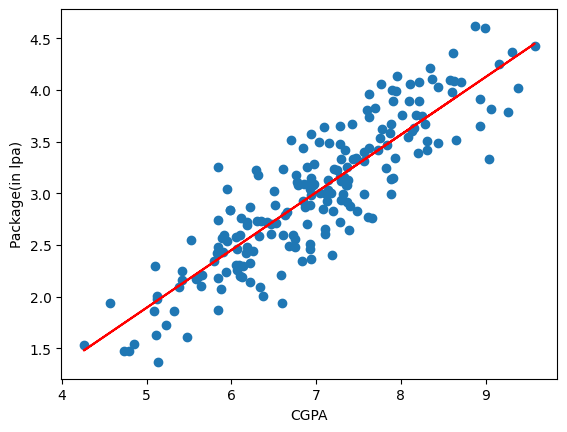

In [11]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

## 5. Evaluate Model with Regression Metrics

We now compare the test-set predictions (`y_pred`) with the actual values (`y_test`).

> **Why test data?** Evaluating on test data estimates how the model performs on **new, unseen students** — not just the students it was trained on. A model that scores well on training data but poorly on test data is **overfitting**.

---

### Metric 1 — Mean Absolute Error (MAE)

**Formula:**

$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

**What it measures:**  
The average size of the errors, ignoring direction. Every error — large or small — is treated equally.

**How to interpret:**  
An MAE of 0.50 on this dataset means: *"On average, the model's package prediction is off by ₹0.50 LPA."* This is directly human-readable because it's in the same unit as the target.

**When to use MAE:**
- When all errors are equally important (no preference for penalizing outliers)
- When you need a metric that non-technical stakeholders can easily understand
- When the data has outliers and you don't want them to dominate the score

**Pros & Cons:**

| Pros | Cons |
|:---|:---|
| Easy to interpret (same unit as target) | Treats small and large errors equally |
| Robust to outliers | Not differentiable at zero (optimization issue) |
| Directly meaningful in business context | Doesn't tell you if errors are systematic |

---

### Metric 2 — Mean Squared Error (MSE)

**Formula:**

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

**What it measures:**  
The average of the **squared** errors. Because of squaring, large errors contribute far more than small ones.

**How to interpret:**  
An MSE of 0.12 means the average squared error is 0.12 LPA². This is hard to interpret directly because the unit is squared, but lower is always better.

**When to use MSE:**
- As a **loss function during model training** (differentiable, smooth)
- When large prediction errors are especially unacceptable (e.g., safety-critical systems)
- When comparing models mathematically

**Pros & Cons:**

| Pros | Cons |
|:---|:---|
| Penalizes large errors heavily (useful when outliers matter) | Units are squared — not directly interpretable |
| Differentiable everywhere — ideal for gradient-based optimization | Sensitive to outliers (a single large error inflates MSE) |
| Widely used as a training loss | Always positive, so direction of errors is lost |

---

### Metric 3 — Root Mean Squared Error (RMSE)

**Formula:**

$$RMSE = \sqrt{MSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

**What it measures:**  
The square root of MSE — it brings the metric back to the **same unit as the target** while still penalizing large errors more than MAE does.

**How to interpret:**  
An RMSE of 0.35 means: *"Typical predictions deviate from the true package by about ₹0.35 LPA, with large errors weighted more."*

**Comparing MAE and RMSE:**  
If `RMSE >> MAE`, it suggests the model is making a few **very large errors** (outliers). If `RMSE ≈ MAE`, errors are consistent in size.

**When to use RMSE:**
- When large errors are more costly than small ones (asymmetric cost)
- As a general-purpose metric when you want interpretability + outlier sensitivity
- When comparing models on the same dataset

**Pros & Cons:**

| Pros | Cons |
|:---|:---|
| Same unit as target (interpretable) | More sensitive to outliers than MAE |
| Penalizes large errors more heavily | Can be misleading if outliers are not genuine |
| Standard metric for regression benchmarks | Always positive, direction of bias is lost |

---

### Metric 4 — R² Score (Coefficient of Determination)

**Formula:**

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

Where:
- $SS_{res}$ = Sum of Squared Residuals (model's unexplained variance)
- $SS_{tot}$ = Total Sum of Squares (total variance in the target)
- $\bar{y}$ = Mean of the actual values

**What it measures:**  
The proportion of variance in the target variable **explained by the model**. R² answers: *"How much better is our model compared to just predicting the mean every time?"*

**How to interpret:**

| R² Value | Interpretation |
|:---:|:---|
| 1.0 | Perfect predictions — model explains all variance |
| 0.78 | Model explains 78% of the variance in package |
| 0.0 | Model is no better than predicting the mean (ȳ) |
| < 0.0 | Model is **worse** than predicting the mean |

**When to use R²:**
- When you want to explain model quality to stakeholders
- When comparing models trained on the **same target and dataset**
- When you need a scale-free, normalized metric

**Pros & Cons:**

| Pros | Cons |
|:---|:---|
| Normalized (0 to 1) — easy to compare across datasets | Always increases (or stays same) when features are added, even useless ones |
| Intuitive: "model explains X% of variance" | Doesn't indicate whether errors are large or small in absolute terms |
| Scale-independent | Can be misleading with too many features |

---

### Metric 5 — Adjusted R² Score

**Formula:**

$$Adjusted\ R^2 = 1 - \frac{(1 - R^2)(n - 1)}{n - k - 1}$$

Where:
- $n$ = number of test samples
- $k$ = number of features (predictors)

**What it measures:**  
A version of R² that **penalizes adding irrelevant features**. Ordinary R² never decreases when you add more features — even random noise features slightly inflate it. Adjusted R² corrects for this.

**How to interpret:**

| Scenario | R² | Adjusted R² |
|:---|:---:|:---:|
| Add a **relevant** feature (e.g., IQ score) | Increases ↑ | Also increases ↑ |
| Add an **irrelevant** feature (e.g., random noise) | Slightly increases ↑ | Decreases ↓ or stays same |

**When to use Adjusted R²:**
- When comparing models with **different numbers of features**
- During **feature selection** — to detect if a new feature actually helps
- Whenever you're building a multi-feature regression model

**Pros & Cons:**

| Pros | Cons |
|:---|:---|
| Penalizes unnecessary features | Harder to interpret than R² for beginners |
| Better for multi-feature model comparison | Can become negative for very poor models |
| Prevents overfitting via feature complexity | Still doesn't tell you about absolute error size |

In [9]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [10]:
y_pred = lr.predict(X_test)

In [14]:
y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [15]:
print("MAE",mean_absolute_error(y_test,y_pred))

MAE 0.2884710931878175


**Interpretation:** MAE ≈ 0.29 LPA — on average, the model's package predictions are off by about ₹0.29 LPA. Since this is in the same unit as the target, it is directly business-meaningful. This is a reasonable error for a salary prediction model.

**Interpretation:** MSE ≈ 0.12 LPA² — the average squared error. The unit (LPA²) is not directly intuitive, but the value being small relative to the target range tells us errors are generally not large. Notice MSE is larger than MAE² (0.29² = 0.084), confirming a few larger errors are pulling the squared average up.

**Interpretation:** RMSE ≈ 0.35 LPA — predictions deviate from the true package by about ₹0.35 LPA on average (with large errors weighted more). Since RMSE (0.35) > MAE (0.29), we know there are a few predictions with larger-than-typical errors. The gap is small here, suggesting the model is fairly consistent.

In [16]:
print("MSE",mean_squared_error(y_test,y_pred))

MSE 0.12129235313495527


In [17]:
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))

RMSE 0.34827051717731616


In [11]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.780730147510384


In [19]:
# Adjusted R2 score
X_test.shape

(40, 1)

## 6. Adjusted R² Score

Adjusted R² accounts for the number of predictors in the model. Unlike R², it penalizes adding irrelevant features.

**Formula:**

$$
Adjusted\ R^2 = 1 - \frac{(1-R^2)(n-1)}{n-k-1}
$$

Where:
- $n$ = number of samples
- $k$ = number of features

In [12]:
n = X_test.shape[0]
k = X_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
print("Adjusted R2 score", adjusted_r2)

Adjusted R2 score 0.7749598882343415


In [13]:
new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(200)

new_df1 = new_df1[['cgpa','random_feature','package']]
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.074249,3.26
1,5.12,0.609002,1.98
2,7.82,0.910975,3.25
3,7.42,0.905046,3.67
4,6.94,0.567904,3.57


---

## 7. Experiment 1: Adding a Random Feature

Let's demonstrate why Adjusted R² is important by adding a **random, uncorrelated feature** to our model.

**Hypothesis:** R² may increase slightly even with a useless feature, but Adjusted R² should decrease or stay the same.

Text(0, 0.5, 'Package(in lpa)')

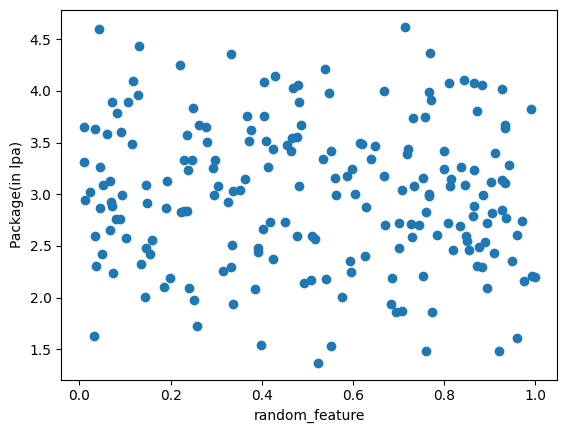

In [22]:
plt.scatter(new_df1['random_feature'],new_df1['package'])
plt.xlabel('random_feature')
plt.ylabel('Package(in lpa)')

In [15]:
X = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]

### Train model with random feature and compare metrics:

In [16]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [25]:
lr = LinearRegression()

In [26]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
y_pred = lr.predict(X_test)

In [28]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.7766735045538148


In [ ]:
n = X_test.shape[0]
k = X_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
print("Adjusted R2 score", adjusted_r2)

0.7646018020972642

In [14]:
new_df2 = df.copy()

new_df2['iq'] = new_df2['package'] + (np.random.randint(-12,12,200)/10)

new_df2 = new_df2[['cgpa','iq','package']]

---

## 8. Experiment 2: Adding a Correlated Feature (IQ)

Now let's add a feature that is **strongly correlated** with the target variable.

The `iq` feature is synthetically created to be highly correlated with `package` (with small random noise).

**Hypothesis:** Both R² and Adjusted R² should increase significantly since this feature provides useful information.

In [31]:
new_df2.sample(5)

,cgpa,iq,package
68,7.56,3.99,2.99
17,5.38,3.19,2.09
65,7.60,4.01,3.81
123,5.10,2.60,2.30
120,5.23,1.33,1.73


Text(0, 0.5, 'Package(in lpa)')

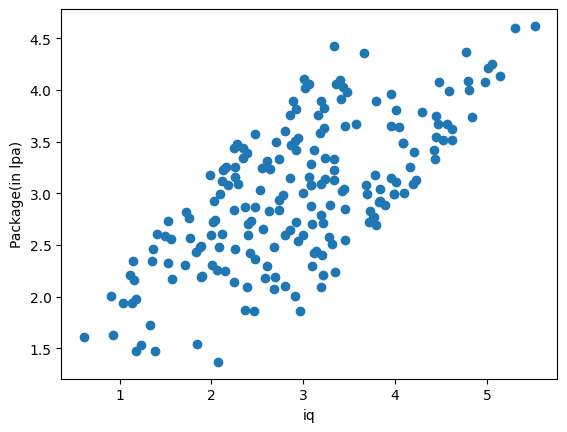

In [32]:
plt.scatter(new_df2['iq'],new_df2['package'])
plt.xlabel('iq')
plt.ylabel('Package(in lpa)')

In [33]:
np.random.randint(-100,100)

-84

In [17]:
X = new_df2.iloc[:,0:2]
y = new_df2.iloc[:,-1]

### Train model with IQ feature and compare metrics:

In [35]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [36]:
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

In [37]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.8378651342017561


In [ ]:
n = X_test.shape[0]
k = X_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
print("Adjusted R2 score", adjusted_r2)

0.8291010874018511

---

## Key Takeaways

1. **MAE** is easy to interpret but treats all errors equally
2. **MSE** penalizes larger errors more heavily
3. **RMSE** is in the same unit as the target variable
4. **R²** measures the proportion of variance explained by the model
5. **Adjusted R²** is preferred when comparing models with different numbers of features - it penalizes unnecessary complexity

### When to use which metric?
- Use **MAE** when all errors are equally important
- Use **RMSE** when large errors are particularly undesirable
- Use **Adjusted R²** when comparing models with different feature counts